# CSE432: Introduction to Machine Learning
## Take-Home Midterm Exam 1

**Time Limit** (not including SDS students): 130 min  
**Allowed resources:** Python, NumPy, pandas, matplotlib, seaborn, scikit-learn, scipy
**Submission format:** Run all cells, then save and submit this file as `Lastname_Firstname_CSE432_Midterm1.ipynb` via the course Canvas.

---

### Instructions

1. Fill in your first and last name in the Setup cell below before doing anything else.
2. Run cells in order from top to bottom. Do not skip cells.
3. For cells marked `# YOUR CODE HERE`, is the part you dev your code. Do not edit the DO NOT EDIT part.
4. Round all reported numeric results to **4 decimal places** unless the question says otherwise.
5. **Changing a number in an answer box to contradict your code output results in a grade of zero for that sub-part.**
6. If a sub-part depends on the output of a previous sub-part and you could not complete the previous part, state a reasonable placeholder value and note it clearly. You will not automatically receive zero.

---

**Total: 106 points**  
Questions: **Q1** (20 pts) | **Q2** (20 pts) | **Q3** (20 pts) | **Q4** (20 pts) | **Q5** (20 pts) | **Q6** (6 pts)

In [1]:
# DO NOT MODIFY THIS CELL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# -------------------------------------------------------
# EDIT HERE (DONT FORGET TO ENTER YOUR NAME)
# Enter your first and last name below (plain letters only, no accents)
FIRST_NAME = "Dean"   # e.g.  "Jane"
LAST_NAME  = "DiCarlo"    # e.g.  "Smith"
# -------------------------------------------------------
_name = (FIRST_NAME + LAST_NAME).lower()
SEED = sum(ord(c) for c in _name if c.isalpha()) % 1000
print("Student:", FIRST_NAME, LAST_NAME)
print("Your random seed:", SEED)

Student: Dean DiCarlo
Your random seed: 142


<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

---
## Q1: Python Data Types and NumPy (20 points)

### Part A: Choosing the Right Data Structure (8 points)

The dictionary below represents one record in a student database:

```python
record = {
    "student_id": 10234,
    "scores": [88, 92, 75, 95, 80],
    "passed_courses": {"CS101", "CS201", "MA101"},
    "metadata": ("Fall", 2024)
}
```

**(A1 -- 2 pts)** What is the key difference between the `scores` list and the `passed_courses`?  
Give one concrete reason you would choose the data type for `passed_courses`.

**(A2 -- 2 pts)** The `metadata` field is a tuple. Why is a tuple more appropriate here than a list?  

**(A3 -- 4 pts)** In the code cell below, write the **function** `add_score(record, new_score)` that:
- Appends `new_score` to `record["scores"]`
- Returns the updated **average** of `record["scores"]`, rounded to 2 decimal places
- Does NOT modify `passed_courses`

Then call your function with `new_score = 85` and print the result.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

In [2]:
record = {
    "student_id": 10234,
    "scores": [88, 92, 75, 95, 80],
    "passed_courses": {"CS101", "CS201", "MA101"},
    "metadata": ("Fall", 2024)
}

# YOUR CODE HERE
# Write the function add_score(record, new_score) and call it with new_score = 85
def add_score(record, new_score) :
    record["scores"].append(new_score)
    avg = (sum(record["scores"]) / len(record["scores"]))
    print(f"{avg:.2f}")

add_score(record, 85)
#print(record["passed_courses"])

85.83


**Answer (A1):**
scores is a list which allows duplicated items, passed courses is a set, which doesn't allow duplicate items and is unordered inherently. In this case passed courses is a set, because if you have a passed course twice, you still have the same completion level as someone who passed once, and it makes look up easier.

**Answer (A2):**
I think a tuple is used here instead of a list because Fall 2024 should be one item together and if its a list instead of one item, it could theoretically be altered and mess up how the record should be stored.

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part B: Solving an Overdetermined Linear System (12 points)

Consider the following overdetermined system of 5 linear equations in three unknowns $w_0$, $w_1$, and $w_2$:

| Row | Equation |
|-----|--------------------------------------------------|
| 1   | $w_0 + 2w_1 + 0.5w_2 = 4.8$  |
| 2   | $1.5w_0 + w_1 + 2w_2 = 7.3$  |
| 3   | $2w_0 + 3w_1 + w_2 = 9.5$    |
| 4   | $0.5w_0 + 2.5w_1 + 1.5w_2 = 6.1$ |
| 5   | $3w_0 + w_1 + 0.5w_2 = 8.4$  |

In matrix form, the system is $A\mathbf{w} = \mathbf{b}$, where $A \in \mathbb{R}^{5 \times 3}$ and $\mathbf{b} \in \mathbb{R}^5$.  
Because there are more equations than unknowns, an exact solution is generally not expected.  
Instead, find the parameter vector $\mathbf{w}$ that best fits all equations by minimizing the squared residual norm $\|A\mathbf{w} - \mathbf{b}\|^2$.
You can do this by solving $A\mathbf{w} = \mathbf{b}$ for $\mathbf{w}$ (See part B2).

**(B1 -- 4 pts)** In the code cell below, construct the coefficient matrix $A$ and the right-hand side vector $\mathbf{b}$ as NumPy arrays.

**(B2 -- 4 pts)** Compute the least-squares solution using this closed form solution:

$$\mathbf{w} = A^{+} \mathbf{b}$$

Print $w_0$, $w_1$, and $w_2$ rounded to 4 decimal places (use f-strings).

**(B3 -- 4 pts)** Compute the predicted values $\hat{\mathbf{b}} = A\mathbf{w}$ and create a plot showing the 5 **observed** values $b_i$ and the 5 **predicted** values $\hat{b}_i$ against the row index (1 through 5). Use distinct markers for each series, add a legend, label both axes, and title the plot `"Observed vs. Predicted"`.

In the answer cell below, report $w_0$, $w_1$, and $w_2$ to 4 decimal places.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

2.1954
1.1258
1.4576


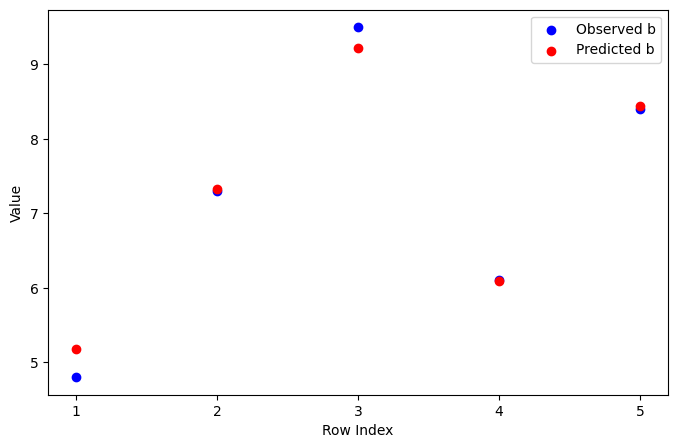

In [3]:
# YOUR CODE HERE

# B1: Construct the coefficient matrix A and vector b
A = np.array([
    [1, 2, 0.5],
    [1.5, 1, 2],
    [2, 3, 1],
    [0.5, 2.5, 1.5],
    [3, 1, 0.5]])
b = np.array([4.8, 7.3, 9.5, 6.1, 8.4])

# B2: Compute the least-squares solution
w = np.linalg.pinv(A).dot(b)

# w = ...

# Print w0, w1, w2 rounded to 4 decimal places
print(f"{w[0]:.4f}")
print(f"{w[1]:.4f}")
print(f"{w[2]:.4f}")


# B3: Compute predicted values b_hat
b_hat = A.dot(w)
# Plot observed b and predicted b_hat against row indices 1..5
row_indices = np.arange(1, 6)
plt.figure(figsize=(8,5))

plt.scatter(row_indices, b, color="blue", label="Observed b")
plt.scatter(row_indices, b_hat, color="red", label="Predicted b")
plt.xlabel("Row Index")
plt.ylabel("Value")
plt.xticks(row_indices)
plt.legend()


plt.show()


**Answer (B2):**

- $w_0$ = 2.1954
- $w_1$ = 1.1258
- $w_2$ = 1.4576

---
## Q2: Data Wrangling (20 points)

Run the cell below to load the Palmer Penguins dataset.

In [4]:
# DO NOT MODIFY THIS CELL
penguins = sns.load_dataset("penguins")
print("Shape:", penguins.shape)
penguins.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part A: Cleaning (6 points)

**(A1 -- 2 pts)** How many rows contain at least one missing value? Report the exact count.

**(A2 -- 2 pts)** Drop all rows that have any missing value. Assign the cleaned result to `df`. How many rows remain?

**(A3 -- 2 pts)** The `sex` column contains the strings `"Male"` and `"Female"`. Add a new column `sex_numeric` where `Male = 1` and `Female = 0`. Do not drop the original `sex` column.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

In [5]:
# YOUR CODE HERE
# A1: Count rows with at least one missing value
print(penguins.isna().any(axis=1).sum())

# A2: Drop rows with any NaN, assign to df, print shape
dropped = penguins.dropna()
print(dropped.shape)

# A3: Add sex_numeric column (Male=1, Female=0) to df
dropped["sex_numeric"] = dropped["sex"].map({"Male": 1, "Female":0})

11
(333, 7)


**Answer (A1):** Rows with at least one missing value: 11

**Answer (A2):** Rows remaining after dropping NaNs: 333

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part B: Aggregation (8 points)

**(B1 -- 4 pts)** Using `df`, create a **pivot table** that shows the mean `body_mass_g` for each combination of `species` (rows) and `sex` (columns). Assign it to `pt` and display it.

**(B2 -- 4 pts)** Using `df.groupby()`, find the **island** with the highest mean `flipper_length_mm`. Print the island name and its mean value rounded to 2 decimal places.

In the answer cell below, report the **exact value** from your `pt` for the cell `(Chinstrap, Female)` (rounded to 2 decimal places).

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

In [8]:
# YOUR CODE HERE
# B1: Pivot table -- mean body_mass_g by species (rows) and sex (columns)
pt = pd.pivot_table(
    data=penguins,
    values="body_mass_g",
    index="species",
    columns="sex",
    aggfunc="mean"
)
print(pt)

# B2: Island with highest mean flipper_length_mm using groupby
island = penguins.groupby("island")["flipper_length_mm"].mean()
print(island)

max = island.max()
maxIsle = island.idxmax()

print(f"{maxIsle} {max:.2f}")

sex             Female         Male
species                            
Adelie     3368.835616  4043.493151
Chinstrap  3527.205882  3938.970588
Gentoo     4679.741379  5484.836066
island
Biscoe       209.706587
Dream        193.072581
Torgersen    191.196078
Name: flipper_length_mm, dtype: float64
Biscoe 209.71


**Answer (B1):** `pt` value for (Chinstrap, Female) = 3527.21 g

**Answer (B2):** Island with highest mean flipper length: Biscoe (mean = 209.71 mm)

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part C: Conceptual (6 points)

**(C1 -- 2 pts)** What is the practical difference between `df.pivot_table()` and `df.groupby()`?  
Describe a scenario where you would use each one.

**(C2 -- 2 pts)** What does the `aggfunc` parameter control in `pivot_table`?  
Give one example of an `aggfunc` other than `"mean"` and explain what it computes.

**(C3 -- 2 pts)** Briefly describe how you used, or would use, `pivot_table()` or `groupby()` in the SER project context. 

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

**Answer (C1):**
The pivot table works as a table based output where you define the indexes and such better so that you can have a nice output display. groupby is more for functionality over presentation, above it was used to just calculate the highest mean of a subset, but wasn't formatted for display. I actually like to use pivot_table more because it looks more like rcode and GGplot and having the format makes more sense to me. If I needed to format a subset of the data that is put on a page or something where visual presentation is necessary I would use pivot_table to organize everything as it should be, then I would use groupby if I just needed to perform operations on a subset.

**Answer (C2):**
Aggfunc is the function that is applied to the data to make the subset, in this case we used mean, but we could use max or median or std, which would, based on the values, index, and columns return the proper operation on the data.

**Answer (C3):**
I would assume that I will be using groupby primarily for the SER project, which I still need to start and spend time beginning the data munging and formatting to prepare for model training very soon. My thought is that I will be grouping by mean of certain emotional characteristics in order to create a classification training set for a future model.

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

---
## Q3: Data Visualization (20 points)

### Part A: The plot the manager (12 points)

The manager of the restaurant is trying to find a very specific pattern in customer behavior. They have asked you to create **one single figure** that allows them to see:

- If the <b>correlation</b> between the bill and the tip changes based on whether it is <b>Lunch or Dinner</b>.</li>
- If <b>Smokers</b> have a different tipping slope than non-smokers.</li>
- How the <b>size of the dining party</b> impacts the tip amount.</li>
- If the <b>Day of the week</b> introduces any categorical variation.</li>

<b>Your Requirement:</b> Using the <code>tips</code> dataset (already provided)

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">


In [ ]:
# DO NOT MODIFY THIS PART
tips_df = sns.load_dataset("tips")
print("Shape:", tips_df.shape)

# YOUR CODE HERE
# Part A: Create the figure


<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part B: Critique Your Own Figure (8 points)

Look carefully at the plot you just produced.

**(B1 -- 4 pts)** List **at least three distinct problems or weaknesses** in YOUR plot. Be specific -- name the channel or encoding involved and explain exactly why it is problematic. Do not write generic statements like "it is hard to read"; instead, identify which specific channel causes the difficulty and why.

**(B2 -- 4 pts)** For each problem you listed in B1, propose one **improvement**. Describe a specific change you could make to the code or design -- not just "make it clearer."

No additional code is required. Write your answers in the cell below.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">


**Answer (B1) -- Problems with my plot:**

1.

2.

3.

**Answer (B2) -- Proposed improvements:**

1.

2.

3.


<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

---
## Q4: Introduction to Machine Learning (20 points)

### Part A: Problem Classification (8 points)

For each scenario below, write the **learning type** and a **one/two sentence justification**.  

1. An autonomous power grid controller must decide every hour whether to draw power from a battery or the main line. It receives a performance metric based on the cost-efficiency of its previous decision but is never told the "correct" decision for any given state.

2. A data scientist is struggling with a high-dimensional dataset of 1,000 columns where many variables are highly correlated. They apply a transformation to create a new set of 5 synthetic features that capture the maximum possible variance of the original data for a scatter plot.

3. A farming cooperative uses satellite imagery to extract the leaf area index of crops. They wish to build a model that maps these continuous physical measurements to the final harvest volume (measured in bushels) recorded over the last decade.

4. A social media platform analyzes 10 million user clickstreams. They have no predefined categories for their users, but they want to partition the user base so that individuals within a set are more similar to each other than to those in other sets.

5. A manufacturing plant captures high-speed sensor data from a turbine. Based on historical logs of "Failure" vs. "Normal Operation," the system must process a live stream of sensor data and trigger an emergency shutoff if the incoming readings match the signature of a known fault.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

**Answer (A):**

1. Type: Reinforcement training
    - Justification: The model is given a performance metric based on its previous decision. This is a way to basically incentivize model action to optimize based on past decisions and a reward metric. It will probably take a while to get to an optimal state as it is a cause and effect kind of relationship here.
2. Type: Supervised training
    - Justification: I think there is enough data here to assume that the scientist is able to identify the variables that are represented in the dataset, and as such the model is able to be tested alongside a proven list. Although the way the text words it by saying he is struggling makes it possible that unsupervised training is the intended inference, but I think that because they are taking the data and transforming it properly into synthetic features it is something supervised for the model.
3. Type: Supervised training
    - Justification: The farming cooperative uses historical data that has already been verified to train a model, the answers are already determined thus training can be proven and have a safe historical verification of success before used on new context.
4. Type: Unsupervised training
    - Justification: This time, unlike the data scientist before, the social media platform has no predefined categories and want to partition the data based on similarity, but there is not a predefined answer or category to verify success.
5. Type: Unsupervised training
    - Justification: I am going to say that this one is unsupervised rather than reinforcement training here because even though the historical logs are already interpreted with a deterministic outcome, new data that has not been interpreted is the training set or testing set they are using, which technically has not yet been verified and could still bring new readings.

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part B: Bias-Variance Tradeoff (6 points)

Three models were trained on the same dataset. Their accuracy scores are:

| Model | Train Accuracy | Test Accuracy |
|-------|---------------|---------------|
| A     | 0.98          | 0.61          |
| B     | 0.74          | 0.72          |
| C     | 0.65          | 0.63          |

**(B1 -- 2 pts)** Which model is most likely **overfitting**? Justify using the numbers.

**(B2 -- 2 pts)** Which model is most likely **underfitting**? Justify using the numbers.

**(B3 -- 2 pts)** Model B has a small gap between train and test accuracy, but both values are moderate. Does this indicate high bias, high variance, or neither? Explain in exactly 2 sentences.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

**Answer (B1):**
Model A is likely overfitting to the training set. The accuracy is so incredibly high for training but low for testing, which means that we can infer that it was overfitted for the specific data and isn't as effective on new testing sets.

**Answer (B2):**
Model C is likely underfitted, because between the training accuracy and test accuracy they are relatively the same variance, but they are not fitted properly to the data, leaving inaccurate results. 

**Answer (B3):**
Model B seems to have low variance, but high bias. It is getting almost the exact same performance on training and testing data, but that result is biased and not tuned to how the accuracy model expects. 

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part C: Error Decomposition (6 points)

The expected prediction error at a point $x$ decomposes as:

$$E\!\left[(y - \hat{f}(x))^2\right] = \mathrm{Bias}^2\!\left[\hat{f}(x)\right] + \mathrm{Var}\!\left[\hat{f}(x)\right] + \sigma^2$$

**(C1 -- 2 pts)** In plain language, what does each of the three terms represent?  
Write one sentence for each term.

**(C2 -- 2 pts)** If you increase model complexity (for example, by adding higher-degree polynomial features), what typically happens to $\mathrm{Bias}^2$ and $\mathrm{Var}$? Why does one go up while the other goes down?

**(C3 -- 2 pts)** The $\sigma^2$ term is called **irreducible error**. Can it be reduced by:  
(a) collecting more training data, or  
(b) increasing model complexity?  
Explain your reasoning in 2 sentences.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

**Answer (C1):**

- $\mathrm{Bias}^2$: This is basically how far the average prediction is from the correct value.
- $\mathrm{Var}$: This is how volatile the function or prediction is, basically the variance (how effective it would be on other testing sets)
- $\sigma^2$: This is additional variance just for noise which is encountered in all applications

**Answer (C2):**
When you use a higher degree polynomial for model fitting, it depends on how the data is correlated but, usually you increase the complexity to better fit the data at hand which reduces bias, but makes variance higher because not all datasets the model will be applied to will have the exact complex correlation

**Answer (C3):**
Depending on the data maybe collecting more data could help in the way of reducing variance, but realistically noise is present in every collection of samples. If the data was perfectly controlled, then you would be living in a vaccuum and there would be no noise because it would be exactly deterministic, but I can't think of an example of this.  
Increasing model complexity would increase variance but reduce bias for the set, however this does nothing to reduce the natural noise or error that comes with collection and thus would not change the irreducible error.

---
## Q5: ML Workflow and Model Diagnosis (20 points)

The task is to predict penguin `species` from four numeric measurements.  
Run the setup cell below before starting Part A.

In [ ]:
# DO NOT MODIFY THIS CELL
try:
    _ = df  # defined in Q2
except NameError: # In case you didn't run Q2 cell or don't have it defined
    df = sns.load_dataset("penguins").dropna().reset_index(drop=True)

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[features].values
y_raw = df["species"].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Feature matrix shape:", X.shape)
print("Label array shape:", y.shape)

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part A: Train, Scale, and Evaluate (10 points)

**(A1 -- 3 pts)** Split `X` and `y` using `test_size=0.20` and `random_state=SEED`.  
Then apply `StandardScaler` -- fit it **only** on `X_train`, then transform both `X_train` and `X_test`.  
State in the answer cell why you must not fit the scaler on the test set.

**(A2 -- 3 pts)** Train `LogisticRegression(max_iter=1000, random_state=SEED)` on the scaled training data (you're free to use documentation or the book).

**(A3 -- 4 pts)** Report:
- Training accuracy (4 decimal places)
- Test accuracy (4 decimal places)
- Confusion matrix on the test set, displayed as a `pd.DataFrame` with class names as row and column labels

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

In [ ]:
# YOUR CODE HERE
# A1: Split X, y using test_size=0.20 and random_state=SEED.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
#     Scale using StandardScaler -- fit only on X_train.

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# A2: Train LogisticRegression(max_iter=1000, random_state=SEED)
regression = LogisticRegression(max_iter=1000, random_state=SEED)
regression.fit(X_train, y_train)

prediction = regression.predict(X_test)

# A3: Print train accuracy, test accuracy (4 dp each).
trainAccuracy = regression.score(X_train, y_train)
testAccuracy = regression.score(X_test, y_test)
print(f"{trainAccuracy:.4f}")
print(f"{testAccuracy:.4f}")

#     Display confusion matrix as a labeled DataFrame.
confusion = pd.DataFrame(
    confusion_matrix(y_test, prediction),
    index = [regression.classes_],
    columns = [regression.classes_])
print(confusion)

**Answer (A1):** Why must the scaler be fit only on training data?
You would have data leaking if it was fit on the test data, meaning that the testing wouldn't be properly verifiable, if it had exposure before the transform it would have to be considered part of the training data and you would then need to find additional data to test the output on.

**Answer (A3):**

- Train accuracy: 0.9925
- Test accuracy: 0.9851

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part B: Feature Importance and Removal (6 points)

**(B1 -- 2 pts)** Print the model coefficients for each class (`model.coef_` has shape `[n_classes, n_features]`).  
Identify the feature with the **largest absolute coefficient** across all classes. Report its name and the coefficient value.

**(B2 -- 2 pts)** Remove that feature from `X`, then repeat the full workflow from Part A (same `SEED`, same scaler procedure). Report the new test accuracy.  
Did accuracy increase, decrease, or stay the same?

**(B3 -- 2 pts)** In 2 to 3 sentences, interpret this result. Was the removed feature essential, noisy, or somewhere in between? What does the accuracy change tell you?

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

In [ ]:
# YOUR CODE HERE
# B1: Print feature names alongside their coefficients for each class.
#     Report the feature with the largest absolute coefficient.

# B2: Remove that feature from X, redo the full split-scale-train-evaluate pipeline.
#     Report new test accuracy.

**Answer (B1):** Feature with largest absolute coefficient: ___ (value: ___)

**Answer (B2):** New test accuracy after removing that feature: ___
Change vs original: ___

**Answer (B3):**

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part C: Noise Feature Injection (4 points)

**(C1 -- 2 pts)** Run the cell below to add a synthetic random-noise column to `X`, then retrain using the same workflow (split with `SEED`, scale, `LogisticRegression`). Report the coefficient(s) assigned to `noise_col` by the model.

**(C2 -- 2 pts)** Is the noise coefficient large or small compared to the other features?  
Based on regularization theory, explain in 2 sentences why a well-regularized model should assign a small coefficient to a pure noise feature.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;">

In [ ]:
# DO NOT MODIFY THIS CELL -- noise column creation
rng_noise = np.random.default_rng(SEED)
noise_col = rng_noise.normal(0, 1, size=(X.shape[0], 1))
X_noisy = np.hstack([X, noise_col])
print("X_noisy shape:", X_noisy.shape)

In [ ]:
# YOUR CODE HERE
# Retrain on X_noisy using the same split (SEED), scaler, and LogisticRegression settings.
# Print the coefficients for the noise_col (last column) across all classes.
# Also report the new test accuracy.

**Answer (C1):** Noise column coefficients (one per class): ___

**Answer (C2):**

---
## Q6: Model Complexity and Generalization (6 pts)

An experiment was run in which a sequence of models with increasing flexibility was evaluated on the same dataset. The complexity of each model is described by a single integer called its **degree** -- a higher degree means a richer, more flexible model family that can fit more complex patterns.

The pre-computed training and validation errors are shown below. **You are NOT expected to train any models in this question.** All tasks involve analyzing and interpreting these given numbers.

In this question you will personalize the validation MSE values using your seed, analyze the error curves numerically, and explain the results in terms of the bias-variance tradeoff.

**Original results (before your personalization):**

| Degree | Train MSE | Val MSE (base) |
|--------|-----------|----------------|
|  1     |  42.00    |  45.00         |
|  3     |  21.00    |  24.00         |
|  5     |   8.00    |  10.00         |
|  9     |   1.20    |   6.00         |
| 15     |   0.01    |  22.00         |

Run the setup cell below to generate **your** personalized validation MSE values.
**All analysis in Parts A and B must use your perturbed `val_mse` -- not the table above.**

In [ ]:
# DO NOT MODIFY THIS CELL
degrees      = np.array([1, 3, 5, 9, 15])
train_mse    = np.array([42.0, 21.0, 8.0, 1.2, 0.01])
val_mse_base = np.array([45.0, 24.0, 10.0, 6.0, 22.0])

rng_q6       = np.random.default_rng(SEED + 42)
perturbation = rng_q6.uniform(-1.5, 1.5, size=5)
val_mse      = val_mse_base + perturbation
gen_gap      = val_mse - train_mse

print("Degrees:        ", degrees)
print("Train MSE:      ", np.round(train_mse, 4))
print("Your val MSE:   ", np.round(val_mse, 4))
print("Gen. gap (v-t): ", np.round(gen_gap, 4))

<div style="display:inline-block;border:1.5px solid #FF9800;border-radius:4px;padding:2px 10px;margin-bottom:10px;font-size:0.75em;font-weight:bold;text-transform:uppercase;letter-spacing:0.07em;color:#FF9800;">&#128274;&nbsp;Question -- Do Not Edit</div>

### Part A: Numeric Analysis (6 pts)

**(A1 -- 2 pts)** The setup cell above printed YOUR generalization gap for each degree (val MSE minus train MSE). Fill in the answer table below using those printed values. Then identify the **first degree** at which the gap exceeds **4.0**. If no gap exceeds 4.0, write "none."

**(A2 -- 2 pts)** Compute the "complexity penalty ratio" using your perturbed `val_mse` array:

$$r = \frac{\text{val\_mse}[d=15] - \text{val\_mse}[d=5]}{\text{train\_mse}[d=5] - \text{train\_mse}[d=15]}$$

Report $r$ to 4 decimal places. In one sentence, interpret what $r > 1$ means: what does it say about the cost of adding complexity beyond degree 5?

**(A3 -- 2 pts)** Between degree 5 and degree 9, training MSE drops by $\Delta_\text{train} = 8.0 - 1.2 = 6.8$. Using your perturbed `val_mse`, compute $\text{val\_mse}[d=9] - \text{val\_mse}[d=5]$. Is the validation improvement larger, smaller, or approximately equal to the training improvement? In one sentence, explain what this asymmetry tells you about what is happening to the model in that complexity range.

<div style="border: 2px solid rgba(255,152,0,0.3); background-color: rgba(255,152,0,0.2); padding: 2px 6px; border-radius: 2px; line-height: 0.8; min-height: 1px;"></div>

In [ ]:
# YOUR CODE HERE
# A1: Compute and print the generalization gap (val_mse - train_mse) for each degree.
#     Identify and print the first degree where the gap exceeds 4.0
#     (print "none" if no such degree exists).

# A2: Compute r = (val_mse[d=15] - val_mse[d=5]) / (train_mse[d=5] - train_mse[d=15]).
#     Use index positions: degrees are at indices 0,1,2,3,4 for 1,3,5,9,15.
#     Print r to 4 decimal places.

# A3: Compute val_mse[d=9] - val_mse[d=5] using your perturbed val_mse.
#     Print the result and compare it to delta_train = 8.0 - 1.2 = 6.8.

**Answer (A1):**

| Degree | Your Gen. Gap |
|--------|--------------|
| 1      |              |
| 3      |              |
| 5      |              |
| 9      |              |
| 15     |              |

First degree where gap > 4.0: ___

**Answer (A2):** $r =$ ___

Interpretation (1 sentence):

**Answer (A3):** Val MSE change from degree 5 to degree 9: ___

Comparison to $\Delta_\text{train} = 6.8$ (larger / smaller / approximately equal):

What this tells you about the model in this complexity range:

---
## Submission Checklist

Before submitting, confirm each item:

- [x] I replaced `First` and `Last` with my actual first and last name in the Setup cell.
- [x] I ran all cells from top to bottom with no errors.
- [x] All numeric answers in answer boxes match my code output exactly.
- [ ] I answered every written question in the designated answer boxes.
- [x] File is saved as `Lastname_Firstname_CSE432_Midterm1.ipynb`.
- [x] File is submitted via the Canvas (There is an incremental penalty for late submission).

---

*End of Exam*